Mounted at /content/drive
Loading CSV files...
Aligning to BTC 7x24 timeline...
Merging all assets...
Adding US market trading hours flag...
Done! Final shape: (2999498, 29)
[INFO] merged shape (pre-crop): (2999498, 34)
[INFO] merged columns (head): ['Open', 'High', 'Low', 'Close', 'Volume', 'ETH/USD_open', 'ETH/USD_high', 'ETH/USD_low', 'ETH/USD_close', 'EUR/USD_open', 'EUR/USD_high', 'EUR/USD_low', 'EUR/USD_close', 'GLD_open', 'GLD_high']
[INFO] merged shape (cropped): (2630880, 34)
[INFO] number of factors: 29
[INFO] factor list: ['MOM_3', 'MOM_5', 'MOM_10', 'Z_MOM_5', 'Z_MOM_10', 'VOL_5', 'VOL_30', 'VOL_60', 'VOL_RATIO_60', 'VOL_RATIO_5_60', 'BODY_SIZE', 'RANGE_1', 'SHADOW_UP', 'SHADOW_DOWN', 'MA_CLOSE_5', 'MA_CLOSE_20', 'MA_SPREAD_5_20', 'SPREAD_BTC_SPY', 'SPREAD_BTC_ETH', 'SPREAD_BTC_GLD', 'RET_SPY_5', 'RET_ETH_5', 'RET_GLD_5', 'RET_VIXY_5', 'CORR_BTC_SPY_30', 'CORR_BTC_ETH_30', 'US_Trading_Hours', 'MINUTE_SIN', 'MINUTE_COS']
[INFO] df_factors shape: (346597, 71)
[INFO] df_ic sha

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



=== ICIR (daily IC mean / daily IC std) ===
              factor   mean_IC    std_IC      ICIR  num_days
13       SHADOW_DOWN  0.013925  0.090181  0.154408       831
23        RET_VIXY_5  0.008471  0.079284  0.106838       831
7             VOL_60  0.021309  0.282887  0.075325       831
11           RANGE_1  0.010218  0.138240  0.073912       831
21         RET_ETH_5  0.006651  0.108320  0.061401       831
6             VOL_30  0.015594  0.257901  0.060465       831
8       VOL_RATIO_60  0.002620  0.072045  0.036368       831
5              VOL_5  0.005933  0.169096  0.035087       831
25   CORR_BTC_ETH_30  0.003176  0.224340  0.014157       831
27        MINUTE_SIN  0.002798  0.441583  0.006335       831
26  US_Trading_Hours  0.001523  0.321701  0.004733       827
28        MINUTE_COS -0.003217  0.291489 -0.011036       831
12         SHADOW_UP -0.001475  0.093645 -0.015746       831
22         RET_GLD_5 -0.001155  0.067858 -0.017021       831
24   CORR_BTC_SPY_30 -0.005726  0.211596

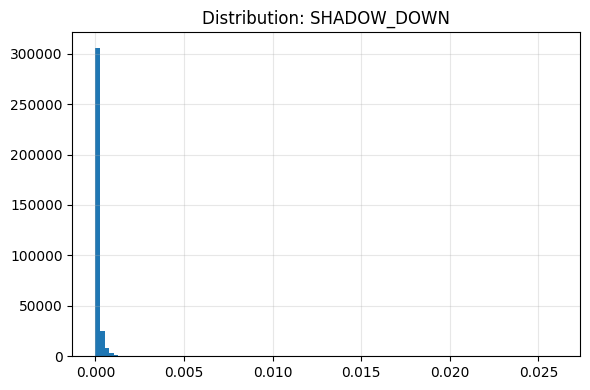

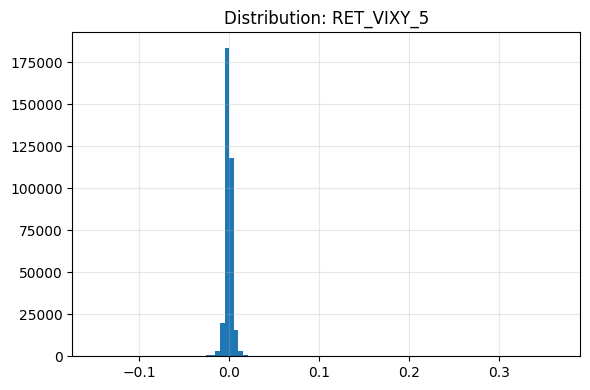

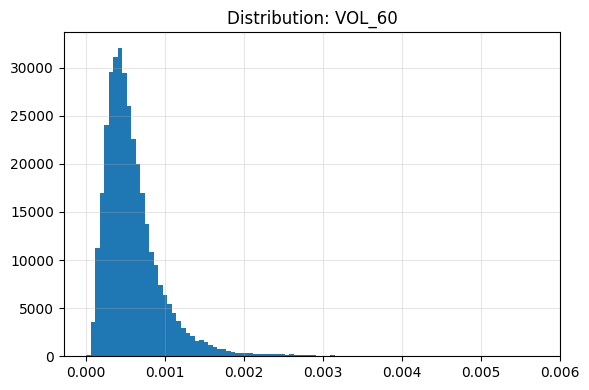

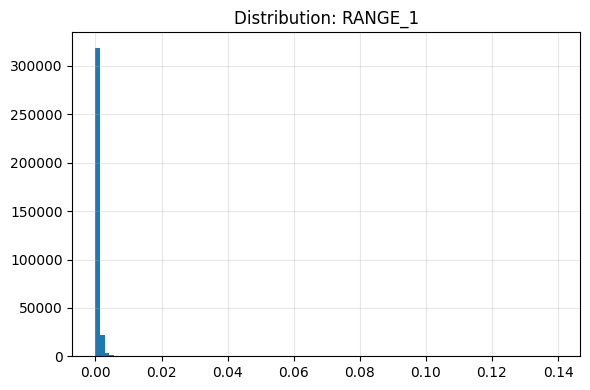

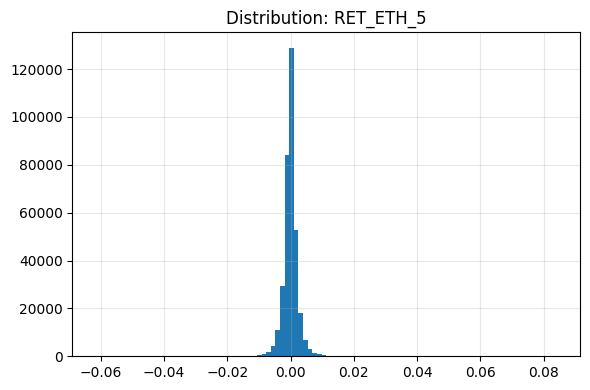

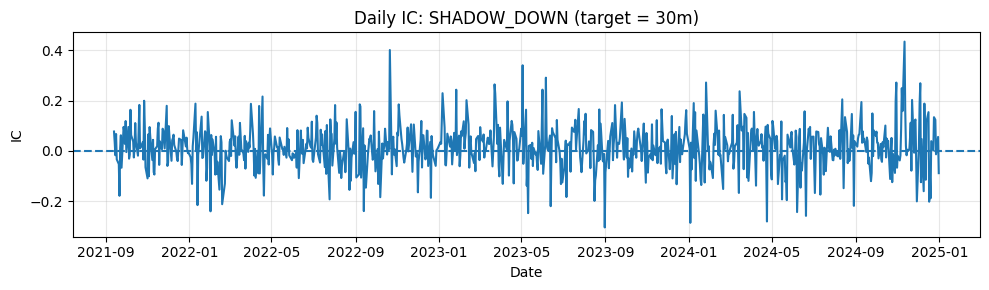

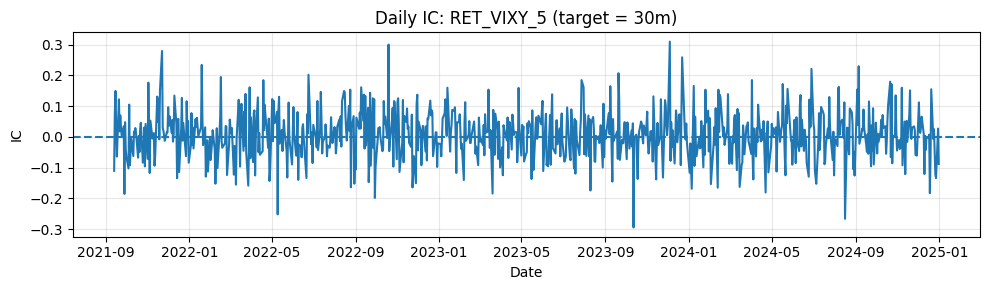

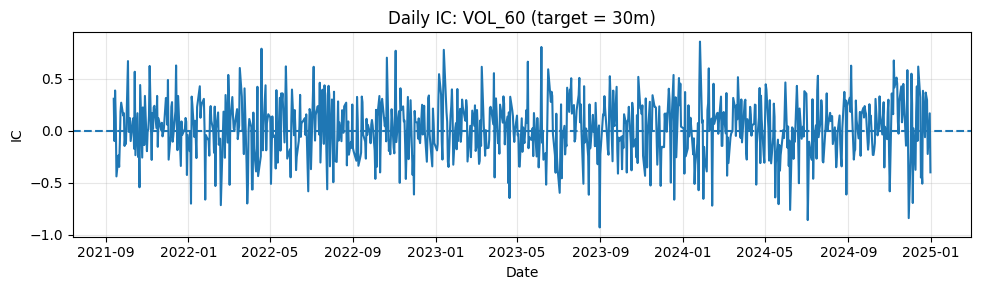

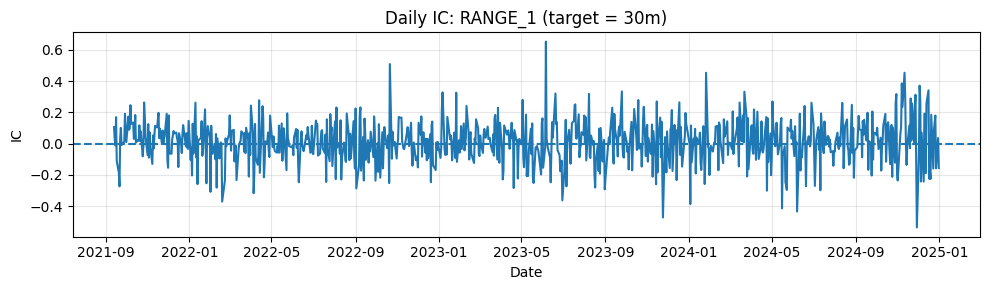

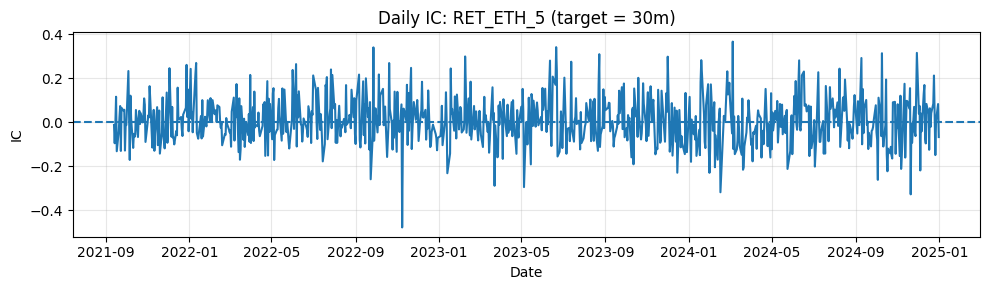


=== Correlation among top ICIR factors ===
             SHADOW_DOWN  RET_VIXY_5    VOL_60   RANGE_1  RET_ETH_5
SHADOW_DOWN     1.000000    0.001674  0.360204  0.523166   0.001281
RET_VIXY_5      0.001674    1.000000  0.000028  0.002512  -0.002134
VOL_60          0.360204    0.000028  1.000000  0.576905   0.011217
RANGE_1         0.523166    0.002512  0.576905  1.000000   0.005440
RET_ETH_5       0.001281   -0.002134  0.011217  0.005440   1.000000


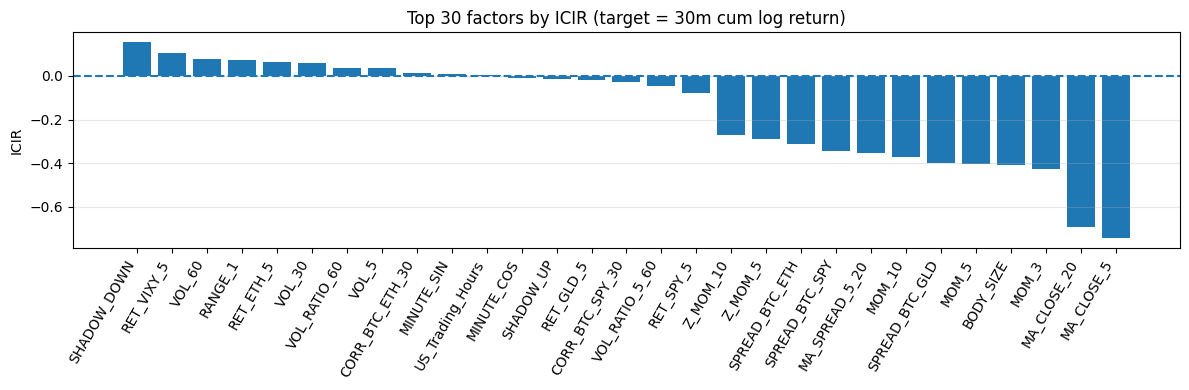

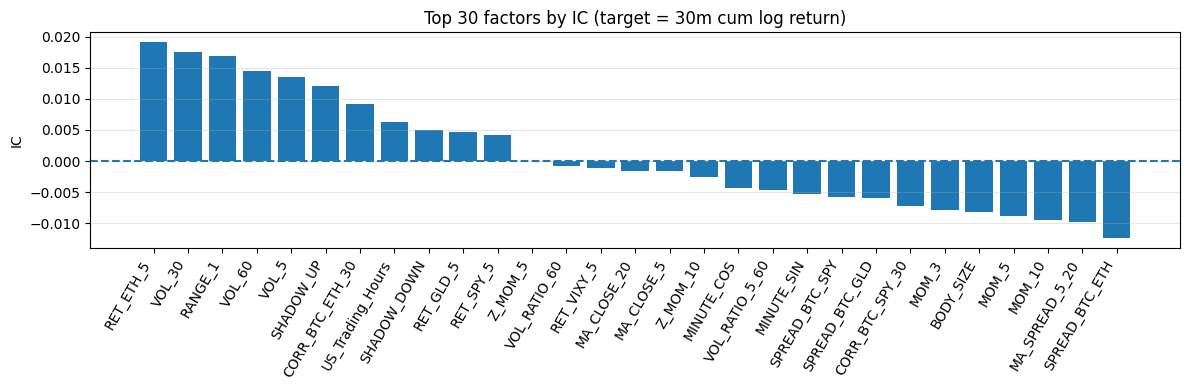

In [2]:
"""
Minute-level factor engineering + IC/ICIR evaluation (30-minute horizon)

This script:
1) Loads minute-aligned BTC + macro assets (ETH, SPY, GLD, VIXY) from local CSVs via data_loader.py
2) Builds a richer set of minute-level factors (purely using past/current information)
3) Defines the target as the next 30-minute cumulative log return of BTC
4) Computes:
   - Overall IC (full sample correlation)
   - Daily IC series and ICIR (mean(daily IC) / std(daily IC))
5) Produces basic plots:
   - Top factors by ICIR
   - Top factors by IC
   - Daily IC curves for selected factors
   - Factor distributions (histograms) for top ICIR factors
   - Correlation matrix among top ICIR factors
"""

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Colab + Drive setup
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass



# Google Drive Project paths
CODE_DIR = "/content/drive/MyDrive/Colab Notebooks/Mf 703/Mf 703 Final Project/"
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Mf 703/Mf 703 Final Project/data/"

sys.path.append(CODE_DIR)

from data_loader import build_merged_dataset, preprocess_merged_df


# Input CSV files
btc_path  = os.path.join(DATA_DIR, "btcusd_1-min_data.csv")
eth_path  = os.path.join(DATA_DIR, "ETH_USD_1min_2020_2025.csv")
eur_path  = os.path.join(DATA_DIR, "EUR_USD_1min_2020_2025.csv")  # not used in factors below, but kept for merged completeness
gld_path  = os.path.join(DATA_DIR, "GLD_1min_2020_2025.csv")
spy_path  = os.path.join(DATA_DIR, "SPY_1min_2020_2025.csv")
vixy_path = os.path.join(DATA_DIR, "VIXY_1min_2020_2025.csv")


# Load + merge + preprocess
merged = build_merged_dataset(
    btc_path=btc_path,
    eth_path=eth_path,
    eur_path=eur_path,
    gld_path=gld_path,
    spy_path=spy_path,
    vixy_path=vixy_path,
)

merged = preprocess_merged_df(merged)

print(f"[INFO] merged shape (pre-crop): {merged.shape}")
print(f"[INFO] merged columns (head): {list(merged.columns[:15])}")

merged = merged.loc["2020-01-01":"2024-12-31"].copy()
print(f"[INFO] merged shape (cropped): {merged.shape}")



# Utilities
def _require_columns(df: pd.DataFrame, cols: list[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


def _to_ny_minute_of_day(index: pd.DatetimeIndex) -> np.ndarray:
    """
    Convert index to America/New_York (robust to naive/UTC-aware index) and return minute_of_day [0..1439].
    """
    idx = index
    if idx.tz is None:
        # If timestamps are naive, treat them as UTC by default.
        idx = idx.tz_localize("UTC")
    idx = idx.tz_convert("America/New_York")
    return (idx.hour * 60 + idx.minute).to_numpy()



# Factor engineering (richer set)
def add_rich_minute_factors(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """
    Build a set of minute-level factors using BTC OHLCV and macro assets (ETH, SPY, GLD, VIXY).

    All factors must be "past-only": no future leakage.
    """
    df = df.copy()

    required = [
        "Open", "High", "Low", "Close", "Volume",
        "SPY_close", "ETH/USD_close", "GLD_close", "VIXY_close",
        "US_Trading_Hours",
    ]
    _require_columns(df, required)

    # 1-min log returns
    df["ret_btc"]  = np.log(df["Close"] / df["Close"].shift(1))
    df["ret_spy"]  = np.log(df["SPY_close"] / df["SPY_close"].shift(1))
    df["ret_eth"]  = np.log(df["ETH/USD_close"] / df["ETH/USD_close"].shift(1))
    df["ret_gld"]  = np.log(df["GLD_close"] / df["GLD_close"].shift(1))
    df["ret_vixy"] = np.log(df["VIXY_close"] / df["VIXY_close"].shift(1))

    # A) BTC momentum & volatility
    df["MOM_3"]  = df["ret_btc"].rolling(3).sum()
    df["MOM_5"]  = df["ret_btc"].rolling(5).sum()
    df["MOM_10"] = df["ret_btc"].rolling(10).sum()

    roll5  = df["ret_btc"].rolling(5)
    roll10 = df["ret_btc"].rolling(10)
    df["sum_ret_5"]  = roll5.sum()
    df["vol_5"]      = roll5.std()
    df["sum_ret_10"] = roll10.sum()
    df["vol_10"]     = roll10.std()

    df["Z_MOM_5"]  = df["sum_ret_5"]  / (df["vol_5"]  + 1e-8)
    df["Z_MOM_10"] = df["sum_ret_10"] / (df["vol_10"] + 1e-8)

    df["VOL_5"]  = df["ret_btc"].rolling(5).std()
    df["VOL_30"] = df["ret_btc"].rolling(30).std()
    df["VOL_60"] = df["ret_btc"].rolling(60).std()

    vol_mean_60 = df["Volume"].rolling(60).mean()
    df["VOL_RATIO_60"]   = df["Volume"] / (vol_mean_60 + 1e-8)
    df["VOL_RATIO_5_60"] = df["VOL_5"] / (df["VOL_60"] + 1e-8)


    # B) Candle-shape features (1-min bar geometry)
    df["BODY_SIZE"] = (df["Close"] - df["Open"]) / df["Open"]
    df["RANGE_1"]   = (df["High"] - df["Low"]) / df["Open"]
    df["SHADOW_UP"] = (df["High"] - df[["Open", "Close"]].max(axis=1)) / df["Open"]
    df["SHADOW_DOWN"] = (df[["Open", "Close"]].min(axis=1) - df["Low"]) / df["Open"]


    # C) Moving-average level/spread
    df["MA_CLOSE_5"]  = df["Close"].rolling(5).mean()
    df["MA_CLOSE_20"] = df["Close"].rolling(20).mean()
    df["MA_SPREAD_5_20"] = (df["MA_CLOSE_5"] / (df["MA_CLOSE_20"] + 1e-8)) - 1.0


    # D) Cross-asset features
    df["SPREAD_BTC_SPY"] = df["ret_btc"] - df["ret_spy"]
    df["SPREAD_BTC_ETH"] = df["ret_btc"] - df["ret_eth"]
    df["SPREAD_BTC_GLD"] = df["ret_btc"] - df["ret_gld"]

    df["RET_SPY_5"]  = df["ret_spy"].rolling(5).sum()
    df["RET_ETH_5"]  = df["ret_eth"].rolling(5).sum()
    df["RET_GLD_5"]  = df["ret_gld"].rolling(5).sum()
    df["RET_VIXY_5"] = df["ret_vixy"].rolling(5).sum()

    df["CORR_BTC_SPY_30"] = df["ret_btc"].rolling(30).corr(df["ret_spy"])
    df["CORR_BTC_ETH_30"] = df["ret_btc"].rolling(30).corr(df["ret_eth"])


    # E) Time-of-day structure
    minute_of_day = _to_ny_minute_of_day(df.index)
    df["MINUTE_SIN"] = np.sin(2.0 * np.pi * minute_of_day / 1440.0)
    df["MINUTE_COS"] = np.cos(2.0 * np.pi * minute_of_day / 1440.0)

    factor_cols = [
        "MOM_3", "MOM_5", "MOM_10",
        "Z_MOM_5", "Z_MOM_10",
        "VOL_5", "VOL_30", "VOL_60",
        "VOL_RATIO_60", "VOL_RATIO_5_60",
        "BODY_SIZE", "RANGE_1", "SHADOW_UP", "SHADOW_DOWN",
        "MA_CLOSE_5", "MA_CLOSE_20", "MA_SPREAD_5_20",
        "SPREAD_BTC_SPY", "SPREAD_BTC_ETH", "SPREAD_BTC_GLD",
        "RET_SPY_5", "RET_ETH_5", "RET_GLD_5", "RET_VIXY_5",
        "CORR_BTC_SPY_30", "CORR_BTC_ETH_30",
        "US_Trading_Hours", "MINUTE_SIN", "MINUTE_COS",
    ]

    df = df.dropna(subset=factor_cols + ["Close"])
    return df, factor_cols


df_factors, factor_cols = add_rich_minute_factors(merged)
print(f"[INFO] number of factors: {len(factor_cols)}")
print(f"[INFO] factor list: {factor_cols}")
print(f"[INFO] df_factors shape: {df_factors.shape}")



# Calculate next-30min cumulative log return
df_ic = df_factors.copy()
df_ic["target_cum_return_30m"] = np.log(df_ic["Close"].shift(-30) / df_ic["Close"])
df_ic = df_ic.dropna(subset=["target_cum_return_30m"])

print(f"[INFO] df_ic shape (after target): {df_ic.shape}")

# Date key for daily IC series
df_ic["date"] = df_ic.index.date



# IC (overall)
ic_values = {f: df_ic[f].corr(df_ic["target_cum_return_30m"]) for f in factor_cols}
ic_table = (
    pd.DataFrame.from_dict(ic_values, orient="index", columns=["IC"])
    .sort_values("IC", ascending=False)
)

print("\n=== Overall IC (target = 30m cum log return) ===")
print(ic_table)



# Daily IC series + ICIR
daily_ic_dict = {}
for f in factor_cols:
    # Use only [f, target] columns to avoid pandas groupby.apply warnings
    s = (
        df_ic.groupby("date")[[f, "target_cum_return_30m"]]
        .apply(lambda x: x[f].corr(x["target_cum_return_30m"]))
        .dropna()
    )
    daily_ic_dict[f] = s

icir_rows = []
for f, s in daily_ic_dict.items():
    mean_ic = s.mean()
    std_ic  = s.std()
    icir    = mean_ic / std_ic if std_ic and std_ic > 0 else np.nan
    icir_rows.append(
        {"factor": f, "mean_IC": mean_ic, "std_IC": std_ic, "ICIR": icir, "num_days": len(s)}
    )

icir_table = pd.DataFrame(icir_rows).sort_values("ICIR", ascending=False)

print("\n=== ICIR (daily IC mean / daily IC std) ===")
print(icir_table)



# Focus set: top/bottom factors by ICIR
top_k = 5
top_factors = icir_table.head(top_k)["factor"].tolist()
bottom_factors = icir_table.tail(top_k)["factor"].tolist()

print(f"\n[INFO] Top {top_k} by ICIR: {top_factors}")
print(f"[INFO] Bottom {top_k} by ICIR: {bottom_factors}")



# Plots
# 1) Histograms for top ICIR factors
for f in top_factors:
    plt.figure(figsize=(6, 4))
    plt.hist(df_ic[f].dropna(), bins=100)
    plt.title(f"Distribution: {f}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2) Daily IC curves for top ICIR factors
for f in top_factors:
    s = daily_ic_dict[f]
    plt.figure(figsize=(10, 3))
    plt.plot(s.index, s.values)
    plt.axhline(0, linestyle="--")
    plt.title(f"Daily IC: {f} (target = 30m)")
    plt.xlabel("Date")
    plt.ylabel("IC")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3) Correlation matrix among top ICIR factors (same timestamps)
corr_top = df_ic[top_factors].corr()
print("\n=== Correlation among top ICIR factors ===")
print(corr_top)

# 4) Bar charts: top-N by ICIR and top-N by IC (sorted independently)
top_n = 30

# Top by ICIR
icir_sorted = icir_table.sort_values("ICIR", ascending=False).head(top_n).set_index("factor")["ICIR"]
plt.figure(figsize=(12, 4))
x = np.arange(len(icir_sorted))
plt.bar(x, icir_sorted.values)
plt.axhline(0, linestyle="--")
plt.xticks(x, icir_sorted.index, rotation=60, ha="right")
plt.ylabel("ICIR")
plt.title(f"Top {top_n} factors by ICIR (target = 30m cum log return)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Top by IC
ic_sorted = ic_table["IC"].sort_values(ascending=False).head(top_n)
plt.figure(figsize=(12, 4))
x = np.arange(len(ic_sorted))
plt.bar(x, ic_sorted.values)
plt.axhline(0, linestyle="--")
plt.xticks(x, ic_sorted.index, rotation=60, ha="right")
plt.ylabel("IC")
plt.title(f"Top {top_n} factors by IC (target = 30m cum log return)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
